## By-keyword EDA

Data source: `data/by_keyword/` (keyword-split article CSVs)

### What this notebook covers
1. Keyword별 기사 개수 분포
2. Keyword별 monthly 기사 개수 line graph

### Additional recommended checks
- 키워드별 상위 사이트(`meta_site_name`) 분포
- 기간 커버리지(최초/최신 publish_date)
- (선택) 기사 텍스트 길이 분포(all_text length)


In [4]:
from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Tuple

import matplotlib.pyplot as plt
import pandas as pd

BY_KEYWORD_DIR = Path("../data/by_keyword")
MANIFEST_PATH = BY_KEYWORD_DIR / "_manifest.csv"

assert MANIFEST_PATH.exists(), f"Missing manifest: {MANIFEST_PATH.resolve()}"
manifest = pd.read_csv(MANIFEST_PATH)
manifest

,key_word,row_count,file_name
0,corn and (price or demand or supply or inventory),32178,corn_and_price_or_demand_or_supply_or_inventor...
1,wheat and (price or demand or supply or invent...,25191,wheat_and_price_or_demand_or_supply_or_invento...
2,rice and (price or demand or supply or inventory),21934,rice_and_price_or_demand_or_supply_or_inventor...
3,united states department of agriculture,13084,united_states_department_of_agriculture.csv
4,soybean and (price or demand or supply or inve...,7617,soybean_and_price_or_demand_or_supply_or_inven...
5,national agricultural statistics service,1343,national_agricultural_statistics_service.csv
6,sorghum and (price or demand or supply or inve...,867,sorghum_and_price_or_demand_or_supply_or_inven...
7,"""soybean oil"" and (production or outputs or su...",453,soybean_oil_and_production_or_outputs_or_suppl...
8,"""soybean production""",446,soybean_production.csv
9,"""soy oil"" and (production or outputs or suppli...",330,soy_oil_and_production_or_outputs_or_supplies_...


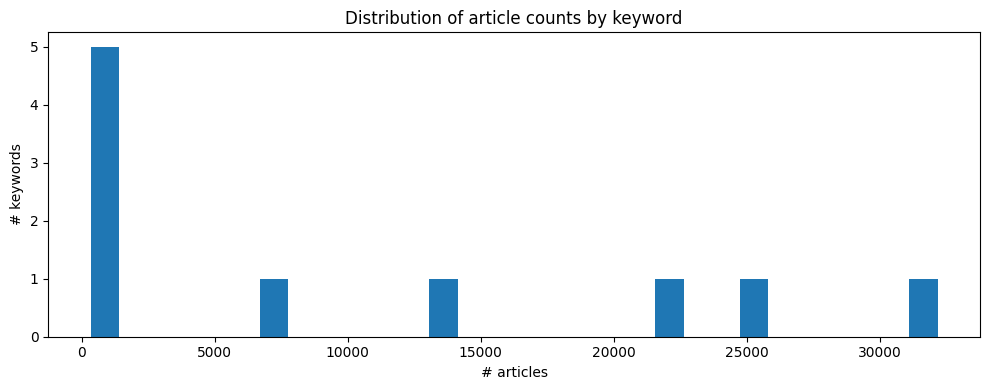

/var/folders/hs/nd90l5s14jq58h388yrwnhf00000gn/T/ipykernel_22689/2892703065.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


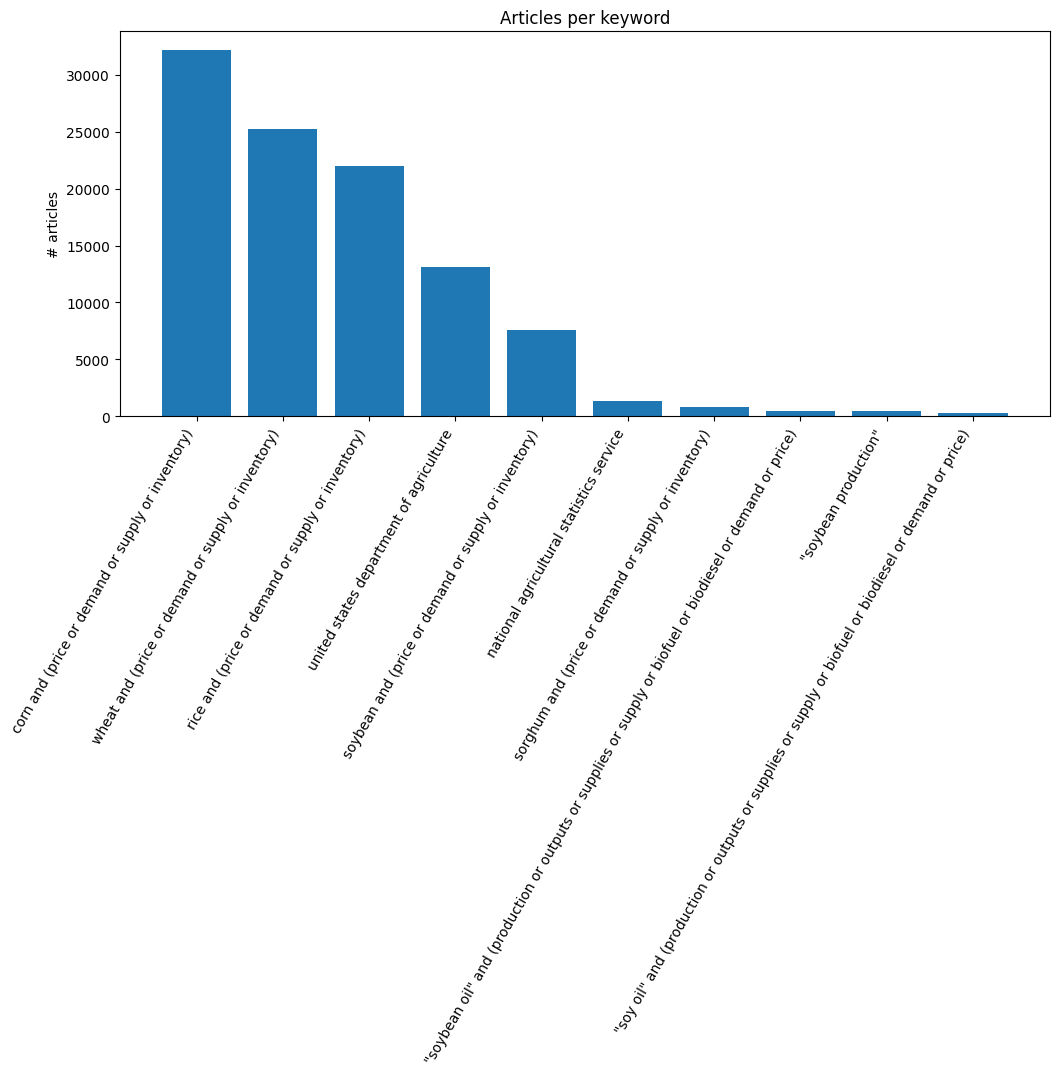

,key_word,row_count,file_name
0,corn and (price or demand or supply or inventory),32178,corn_and_price_or_demand_or_supply_or_inventor...
1,wheat and (price or demand or supply or invent...,25191,wheat_and_price_or_demand_or_supply_or_invento...
2,rice and (price or demand or supply or inventory),21934,rice_and_price_or_demand_or_supply_or_inventor...
3,united states department of agriculture,13084,united_states_department_of_agriculture.csv
4,soybean and (price or demand or supply or inve...,7617,soybean_and_price_or_demand_or_supply_or_inven...
5,national agricultural statistics service,1343,national_agricultural_statistics_service.csv
6,sorghum and (price or demand or supply or inve...,867,sorghum_and_price_or_demand_or_supply_or_inven...
7,"""soybean oil"" and (production or outputs or su...",453,soybean_oil_and_production_or_outputs_or_suppl...
8,"""soybean production""",446,soybean_production.csv
9,"""soy oil"" and (production or outputs or suppli...",330,soy_oil_and_production_or_outputs_or_supplies_...


In [10]:
### 1) 키워드별 기사 개수 분포

m = manifest.copy()
m = m.sort_values("row_count", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 4))
plt.hist(m["row_count"], bins=30)
plt.title("Distribution of article counts by keyword")
plt.xlabel("# articles")
plt.ylabel("# keywords")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(m["key_word"].astype(str), m["row_count"].astype(int))
plt.xticks(rotation=60, ha="right")
plt.title("Articles per keyword")
plt.ylabel("# articles")
plt.tight_layout()
plt.show()

m

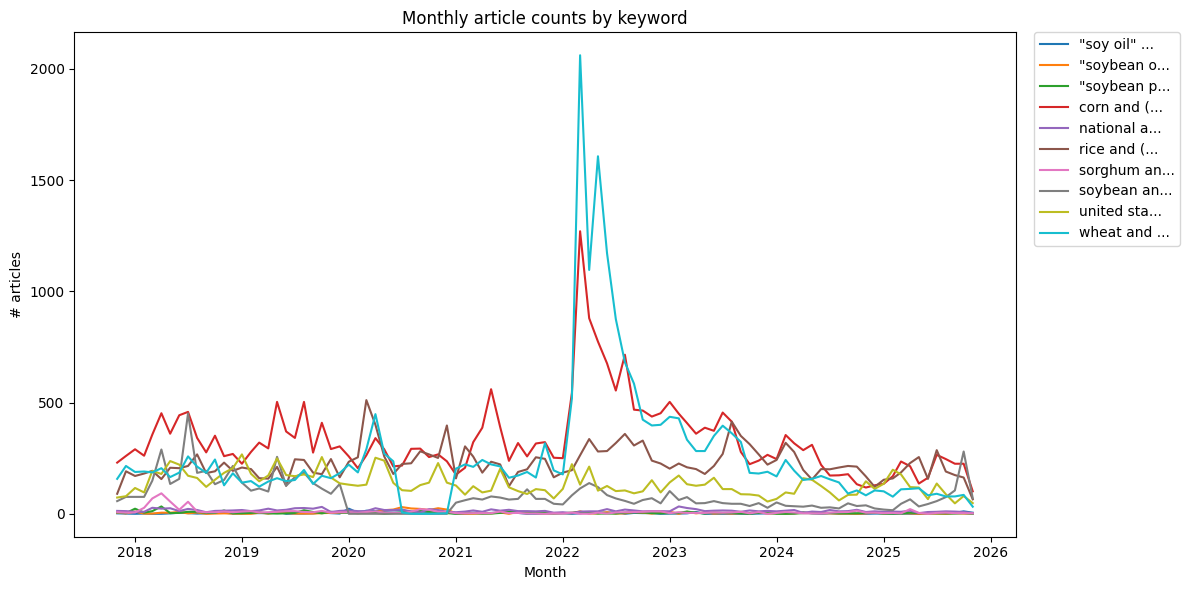

,key_word,month,count
0,"""soy oil"" and (production or outputs or suppli...",2017-11-01,2
1,"""soy oil"" and (production or outputs or suppli...",2017-12-01,1
2,"""soy oil"" and (production or outputs or suppli...",2018-02-01,1
3,"""soy oil"" and (production or outputs or suppli...",2018-05-01,2
4,"""soy oil"" and (production or outputs or suppli...",2018-06-01,5


In [7]:
### 2) 키워드별 monthly 기사 개수 line graph

# Large files: stream read only needed columns
CHUNK_SIZE = 20000


def iter_month_counts(csv_path: Path) -> Dict[str, int]:
    counts: Dict[str, int] = {}
    for ch in pd.read_csv(csv_path, usecols=["publish_date"], chunksize=CHUNK_SIZE):
        dtv = pd.to_datetime(ch["publish_date"], errors="coerce")
        month = dtv.dt.to_period("M").astype(str)
        vc = month.value_counts(dropna=True)
        for k, v in vc.items():
            if k == "NaT":
                continue
            counts[k] = counts.get(k, 0) + int(v)
    return counts


monthly_rows = []
for _, r in manifest.iterrows():
    key = str(r["key_word"])
    fname = str(r["file_name"])
    path = BY_KEYWORD_DIR / fname
    mc = iter_month_counts(path)
    for month, cnt in mc.items():
        monthly_rows.append({"key_word": key, "month": month, "count": cnt})

monthly = pd.DataFrame(monthly_rows)
monthly["month"] = pd.PeriodIndex(monthly["month"], freq="M").to_timestamp()
monthly = monthly.sort_values(["key_word", "month"]).reset_index(drop=True)

pivot = monthly.pivot_table(index="month", columns="key_word", values="count", aggfunc="sum", fill_value=0)


def shorten_label(s: str, max_len: int = 10) -> str:
    s = str(s)
    return s if len(s) <= max_len else (s[:max_len] + "...")


# Build short legend labels (10 chars + '...') and make them unique if needed
short_labels = {c: shorten_label(c, 10) for c in pivot.columns}
rev: Dict[str, List[str]] = {}
for full, short in short_labels.items():
    rev.setdefault(short, []).append(full)
for short, fulls in rev.items():
    if len(fulls) > 1:
        for idx, full in enumerate(fulls, start=1):
            if short.endswith("..."):
                short_labels[full] = f"{short[:-3]}~{idx}..."
            else:
                short_labels[full] = f"{short}~{idx}"


plt.figure(figsize=(12, 6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=short_labels[col])
plt.title("Monthly article counts by keyword")
plt.xlabel("Month")
plt.ylabel("# articles")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

monthly.head()

In [8]:
### 추천 1) 키워드별 상위 사이트 분포 (top N)

TOP_N = 10


def top_sites(csv_path: Path, top_n: int = 10) -> List[Tuple[str, int]]:
    c = Counter()
    for ch in pd.read_csv(csv_path, usecols=["meta_site_name"], chunksize=CHUNK_SIZE):
        c.update(ch["meta_site_name"].dropna().astype(str))
    return c.most_common(top_n)


rows = []
for _, r in manifest.iterrows():
    key = str(r["key_word"])
    path = BY_KEYWORD_DIR / str(r["file_name"])
    for site, cnt in top_sites(path, TOP_N):
        rows.append({"key_word": key, "site": site, "count": cnt})

site_df = pd.DataFrame(rows)
site_df = site_df.sort_values(["key_word", "count"], ascending=[True, False])
site_df.head(30)

,key_word,site,count
90,"""soy oil"" and (production or outputs or suppli...",The Times of India,106
91,"""soy oil"" and (production or outputs or suppli...",Yahoo Entertainment,29
92,"""soy oil"" and (production or outputs or suppli...",Moneycontrol,23
93,"""soy oil"" and (production or outputs or suppli...",BusinessLine,19
94,"""soy oil"" and (production or outputs or suppli...",Business Standard,14
95,"""soy oil"" and (production or outputs or suppli...",Biztoc.com,12
96,"""soy oil"" and (production or outputs or suppli...",Barchart.com,9
97,"""soy oil"" and (production or outputs or suppli...",CNA,9
98,"""soy oil"" and (production or outputs or suppli...",GlobeNewswire,9
99,"""soy oil"" and (production or outputs or suppli...",EURACTIV,7


In [9]:
### 추천 2) 기간 커버리지(최초/최신 publish_date)


def date_range(csv_path: Path) -> Tuple[pd.Timestamp, pd.Timestamp]:
    min_dt = None
    max_dt = None
    for ch in pd.read_csv(csv_path, usecols=["publish_date"], chunksize=CHUNK_SIZE):
        dtv = pd.to_datetime(ch["publish_date"], errors="coerce")
        cur_min = dtv.min()
        cur_max = dtv.max()
        if pd.notna(cur_min):
            min_dt = cur_min if min_dt is None else min(min_dt, cur_min)
        if pd.notna(cur_max):
            max_dt = cur_max if max_dt is None else max(max_dt, cur_max)
    return min_dt, max_dt


ranges = []
for _, r in manifest.iterrows():
    key = str(r["key_word"])
    path = BY_KEYWORD_DIR / str(r["file_name"])
    mn, mx = date_range(path)
    ranges.append({"key_word": key, "min_publish_date": mn, "max_publish_date": mx})

pd.DataFrame(ranges).sort_values("min_publish_date")

,key_word,min_publish_date,max_publish_date
1,wheat and (price or demand or supply or invent...,2017-11-09 00:00:00,2025-11-14 15:31:00
5,national agricultural statistics service,2017-11-09 20:49:10,2025-11-14 00:00:00
3,united states department of agriculture,2017-11-09 21:00:06,2025-11-14 11:00:00
2,rice and (price or demand or supply or inventory),2017-11-09 21:49:42,2025-11-14 21:44:26
4,soybean and (price or demand or supply or inve...,2017-11-09 22:51:58,2025-11-14 23:50:12
0,corn and (price or demand or supply or inventory),2017-11-10 07:47:55,2025-11-14 23:26:40
8,"""soybean production""",2017-11-13 07:40:00,2025-10-27 13:35:43
7,"""soybean oil"" and (production or outputs or su...",2017-11-13 09:36:08,2025-11-04 15:35:53
6,sorghum and (price or demand or supply or inve...,2017-11-14 15:51:27,2025-11-02 04:15:00
9,"""soy oil"" and (production or outputs or suppli...",2017-11-20 13:10:00,2025-11-14 09:04:41
